# Decision Tree Classification
In this notebook, we will walk through building a Decision Tree classifier
using the Titanic dataset. Decision trees are non-parametric models that
can capture nonlinear relationships by recursively splitting the data.
____
We'll cover:
1. Loading and inspecting the dataset.
2. Preprocessing: Handling missing values and encoding categorical data.
3. Splitting the data into training and testing sets.
4. Training a Decision Tree model.
5. Evaluating the model's performance with accuracy, confusion matrix, and a classification report.
6. Visualizing the decision tree.
7. Analyzing model performance using ROC curve and AUC.

## **Step 1: Load and Inspect the Data**

We use the Titanic dataset available from seaborn, which includes details about passengers. This dataset is widely used for classification tasks.

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Load Titanic dataset in seaborn
data = sns.load_dataset('titanic')

# Inspect the dataset
print(data.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


### **Step 2: Data Preprocessing**

Our next step is to prepare the data for modeling:

- **Handling Missing Values:** (OPTIONAL FOR DECISION TREES)
   Here, the line for dropping rows with missing 'age' is commented out.
   Depending on your needs, you might choose to drop these rows or use imputation.

- **Encoding Categorical Variables:**
   Decision tree algorithms can handle numerical inputs, so we convert
   categorical variables (e.g., `sex`) into numeric format using one-hot encoding.

*Note: We use drop_first=True to avoid the dummy variable trap.*

In [2]:
# Handling missing values (optional for decision trees)
data.dropna(subset=['age'], inplace=True) # Need to include of logistic regression, but not decision trees

# Encoding categorical variables
df = pd.get_dummies(data, columns=['sex'], drop_first=True) # Use drop_first = True to avoid "dummy trap"


# Define features and target
features = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']
X = df[features]
y = df['survived']

# Preview the cleaned dataset
print(X.head())
print(y.head())

   pclass   age  sibsp  parch     fare  sex_male
0       3  22.0      1      0   7.2500      True
1       1  38.0      1      0  71.2833     False
2       3  26.0      0      0   7.9250     False
3       1  35.0      1      0  53.1000     False
4       3  35.0      0      0   8.0500      True
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


### **Step 3: Splitting the Data**

We split the dataset into training and testing sets. The training set is used to build the decision tree model, while the testing set is used to evaluate its performance.

In [3]:
from sklearn.model_selection import train_test_split
# Split dataset into training and testing subsets

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42)


### **Step 4: Train the Decision Tree Model**

We initialize and train a Decision Tree classifier.
**Why Decision Trees?**
- They are intuitive and easy to interpret.
- They capture non-linear relationships without needing feature scaling.

Here, we use default parameters, but tuning (e.g., max_depth, min_samples_split) can improve performance and prevent overfitting.

In [4]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train tree classification model

model = DecisionTreeClassifier(random_state = 42,
                               max_depth = 4)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### **Step 5: Evaluate the Model**

We now assess our model’s performance on the test data using several metrics:

- **Accuracy:** The overall proportion of correct predictions.
- **Confusion Matrix:** Displays the number of correct and incorrect predictions.
- **Classification Report:** Provides precision, recall, and F1-score, which help in understanding performance per class.

Accuracy: 0.76


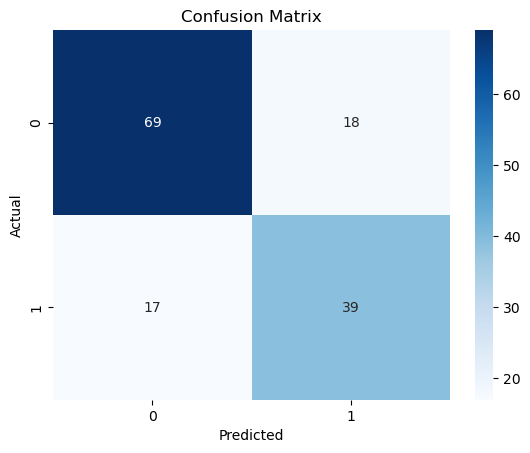

              precision    recall  f1-score   support

           0       0.80      0.79      0.80        87
           1       0.68      0.70      0.69        56

    accuracy                           0.76       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.76      0.76      0.76       143



In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Display classification report
print(classification_report(y_test, y_pred))

### **Step 6: Visualizing the Decision Tree**

One of the advantages of decision trees is their interpretability. We can visualize the tree structure using the graphviz library.
The visualization shows:
- Splitting criteria at each node.
- Feature names used for splits.
- Class distributions within the nodes.

In [10]:
# Import graphviz and export the decision tree to dot format for visualization
import graphviz
from sklearn import tree  # Ensure to import the tree module from sklearn

dot_data = tree.export_graphviz(model, feature_names=X_train.columns,
                                class_names=["Not_Survived", "Survived"],
                                filled=True)

# Generate and display the decision tree graph
graph = graphviz.Source(dot_data)
graph

CalledProcessError: Command '[WindowsPath('dot'), '-Kdot', '-Tsvg']' returned non-zero exit status 3221225477. [stderr: 'Warning: Could not load "C:\\Users\\tommy\\anaconda3\\Library\\bin\\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.\n']

### Explanation of Nodes

* `pclass <= 2.5` — **The Split Condition**. If the passenger's class is ≤ 2.5 (i.e., 1st or 2nd class), go left; otherwise go right.
* `gini = 0.346` — **The Gini Impurity**. Lower means purer; 0.346 indicates moderate mixing of the two classes.
* `samples = 207` — The number of **training samples** that reached this node.
* `value = [46, 161]` — **The Class Distribution**: 46 samples in class 0 (Did Not Survive) and 161 in class 1 (Survived).
* `class = Survived` — **The Majority-Class Prediction**. Since 161 > 46, it predicts Survived.